In [1]:
%load_ext autoreload
%autoreload 2
import os, sys

import sys
sys.path.append("../")

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from src.batch_experiments.utils import ExperimentAnalyser
from src.fmcw_simulation.simulation import FmcwRadar

plt.rc('xtick',labelsize=35)
plt.rc('ytick',labelsize=35)
# mpl.rcParams['figure.dpi'] = 200 
mpl.rcParams['figure.figsize'] = (12, 8) 
mpl.rcParams['axes.titlesize'] = 40
mpl.rcParams['axes.labelsize'] =35
mpl.rcParams['legend.fontsize'] = 30
plt.rcParams['lines.linewidth'] = 4.0
plt.rcParams['text.usetex'] = True
# mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#003052", "#C71818", "#18C7C7", "#70C718", "#7018C7"])
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#6ba0a6", "#d8584e", "#c09651", "#f8c08a", "#8e4f39"])

In [2]:
exp1 = ExperimentAnalyser("../data/recorded_runs/single_target_noise_test.npy")
exp1_low_lambda = ExperimentAnalyser("../data/recorded_runs/single_target_noise_test_low_lambda.npy")
exp1_very_low_lambda = ExperimentAnalyser("../data/recorded_runs/single_target_noise_test_very_low_lambda.npy")
exp1_high_lambda = ExperimentAnalyser("../data/recorded_runs/single_target_noise_test_high_lambda.npy")

In [3]:
exp1.group_by("snr_level", n_bins=100)
exp1_low_lambda.group_by("snr_level", n_bins=100)
exp1_very_low_lambda.group_by("snr_level", n_bins=100)
exp1_high_lambda.group_by("snr_level", n_bins=100)

In [4]:
low_lambda = 1 / exp1_low_lambda.experiment_config['network']['w_scale']
very_low_lambda = 1 / exp1_very_low_lambda.experiment_config['network']['w_scale']
mid_lambda = 1 / exp1.experiment_config['network']['w_scale']
high_lambda = 1 / exp1_high_lambda.experiment_config['network']['w_scale']

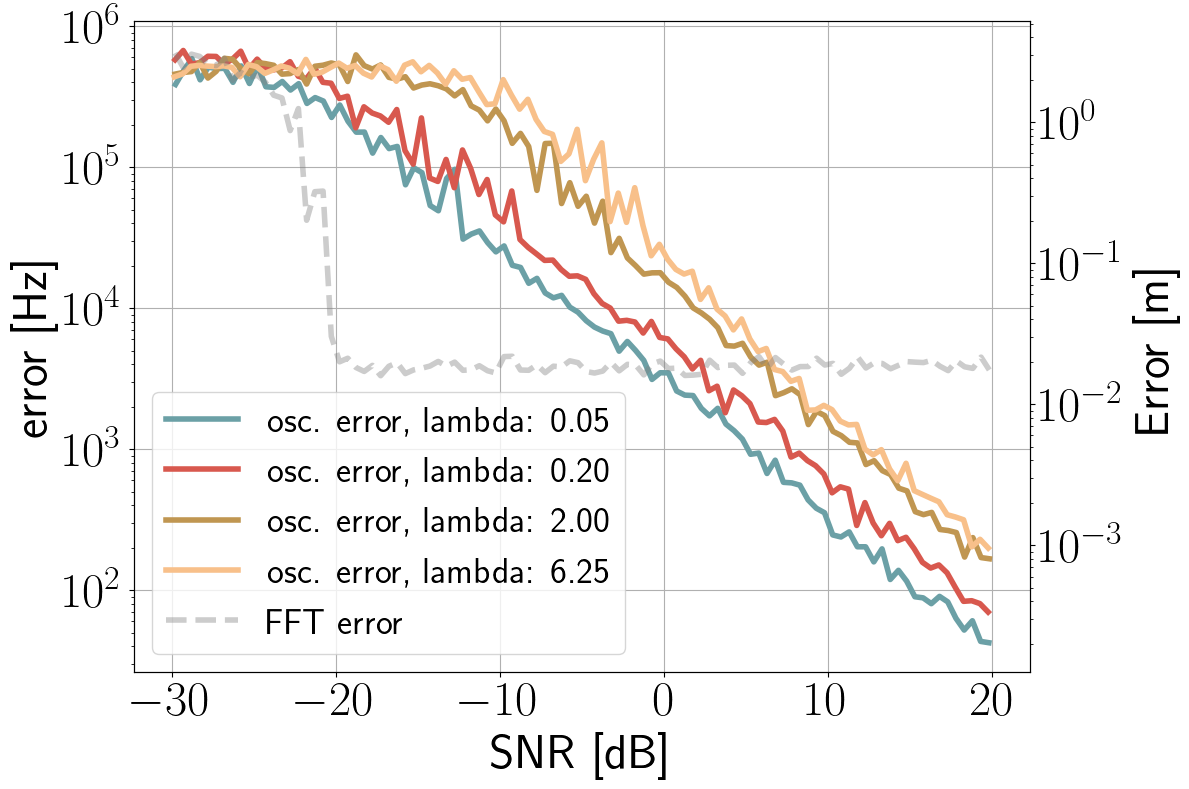

In [7]:
fig, ax = plt.subplots(1)

# exp2_wdot_raw.group_by("gt_range")
fmcw = FmcwRadar(exp1.radar_parameters)

ax.plot(exp1_very_low_lambda.group_data_bins, exp1_very_low_lambda.errors_binned, label=f"osc. error, lambda: {very_low_lambda:.2f}")
ax.plot(exp1_low_lambda.group_data_bins, exp1_low_lambda.errors_binned, label=f"osc. error, lambda: {low_lambda:.2f}")
ax.plot(exp1.group_data_bins, exp1.errors_binned, label=f"osc. error, lambda: {mid_lambda:.2f}")
ax.plot(exp1_high_lambda.group_data_bins, exp1_high_lambda.errors_binned, label=f"osc. error, lambda: {high_lambda:.2f}")

ax.plot(exp1.group_data_bins, exp1.fft_error_binned, label="FFT error", linestyle='--', c="grey", alpha=0.4)
ax.set_yscale("log")

# show the other axis for the range
ax2 = ax.twinx()
ax2.set_ylabel("Error [m]")
ax_ticks = ax.get_yticks()
ax2.set_yticks(fmcw.get_range_from_freq(ax_ticks))
ax2.set_ylim(fmcw.get_range_from_freq(np.array(ax.get_ylim())))
ax2.set_yscale("log")

# ax.gca().invert_xaxis()
ax.legend(fontsize=26)
ax.set_ylabel("error [Hz]")
ax.set_xlabel("SNR [dB]")
# ax.set_xscale("log")
ax.grid()
plt.tight_layout()
# ax.set_ylim([1e2, 1e4])
# plt.title("Single target error, different noise")

plt.savefig("paper_figures/single_target_error_snr.pdf", bbox_inches='tight', dpi=300)

## Error by range

In [28]:
exp2_hann_w2 = ExperimentAnalyser("../data/recorded_runs/single_target_big_range_hann_test_w2.npy")

1189.0822239341373


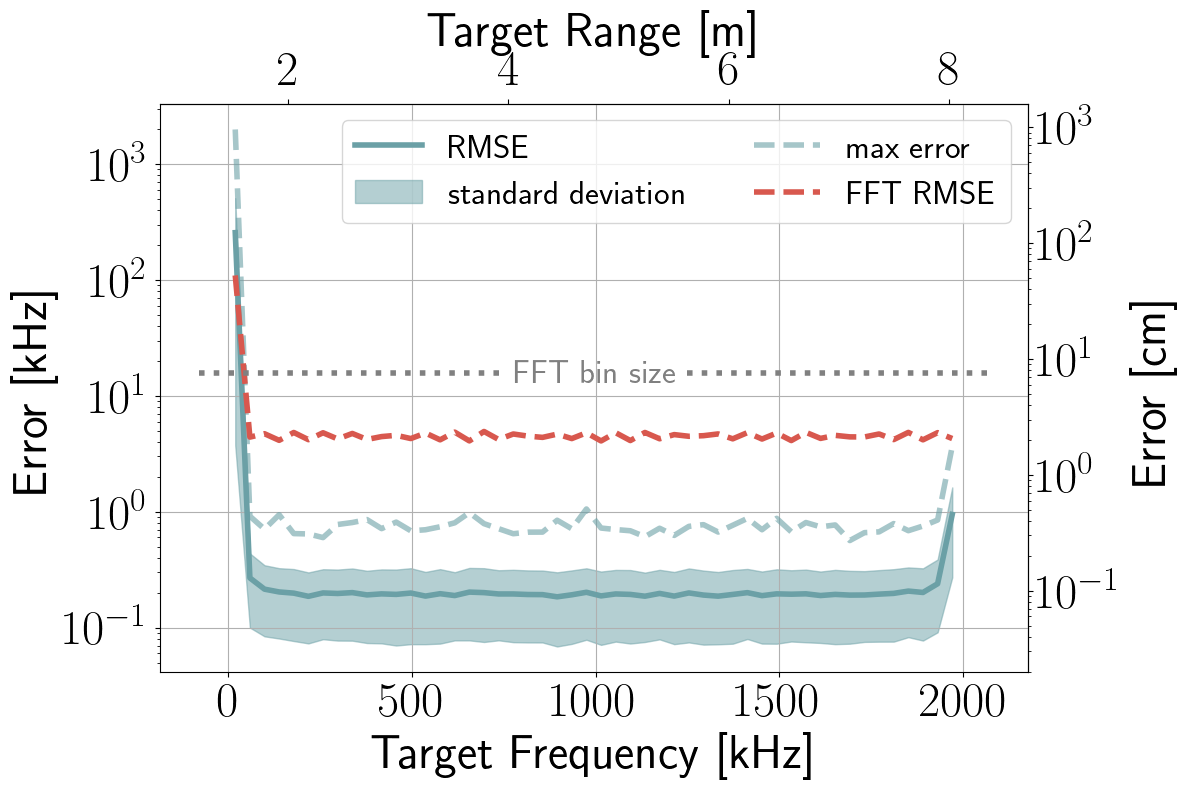

In [29]:

exp2_hann_w2.group_by("gt_freqs", n_bins=50)
freq_scale = 1e-3 # Hz -> kHz
range_scale = 1e2
fmcw = FmcwRadar(exp2_hann_w2.radar_parameters)

fig, ax = plt.subplots(1)

data_bins = exp2_hann_w2.group_data_bins * freq_scale
error_rmse = exp2_hann_w2.rmse_binned * freq_scale
ax.plot(data_bins, error_rmse, label="RMSE")
w_hann_std = exp2_hann_w2.std_binned * freq_scale
w_hann_max = exp2_hann_w2.max_errors_binned * freq_scale
ax.fill_between(data_bins, 
                 error_rmse - w_hann_std, 
                 error_rmse + w_hann_std,
                 alpha=0.5, color="C0", label="standard deviation")
ax.plot(data_bins, w_hann_max,
        c="C0", linestyle="--", label='max error', alpha=0.6)
ax.plot(data_bins, exp2_hann_w2.rmse_fft_binned * freq_scale, 
        label="FFT RMSE", 
        linestyle="--",
        c='C1')

secay = ax.secondary_yaxis(
    'right',
    functions=(
        lambda x: fmcw.get_range_from_freq(x * freq_scale**-1, negative=True) * range_scale,  # kHz → cm
        lambda x: fmcw.get_freq_from_range(x * range_scale**-1) * freq_scale   # m → kHz (inverse)
    )
)
secay.set_ylabel("Error [cm]")

secax = ax.secondary_xaxis(
    'top',
    functions=(
        lambda x: fmcw.get_range_from_freq(x * freq_scale**-1),  # kHz → m
        lambda x: fmcw.get_freq_from_range(x) * freq_scale   # m → kHz (inverse)
    )
)
secax.set_xlabel("Target Range [m]")

def hline_text(x, y, text, color="k", fontsize=12, linestyle="-", ax=None):
    """ draw hline at y interrupted by text at x """
    if ax is None:
        ax = plt.gca()
    text = f" {text} "  # pad with single space
    label = ax.text(x, y, text, color=color, fontsize=fontsize,
                    va="center", ha="center")
    # draw text to get its bounding box
    ax.get_figure().canvas.draw()
    bbox = label.get_window_extent().transformed(ax.transData.inverted())
    # add hlines next to bounding box
    left, right = ax.get_xlim()
    print(bbox.x1)
    ax.hlines([y]*2, [left, bbox.x1+60], [bbox.x0-60, right], color=color, linestyle=linestyle)
hline_text(1000, fmcw.get_freq_from_range(0.075)*freq_scale, "FFT bin size", 
        fontsize=24,
        color="grey",
        linestyle=':')


ax.set_yscale('log')
# ax.set_xlim([0.0, 2])
ax.grid()
ax.legend(fontsize=24, ncol=2)
ax.set_xlabel("Target Frequency [kHz]")
ax.set_ylabel("Error [kHz]")

plt.tight_layout()

plt.savefig("paper_figures/single_target_error_range.pdf", bbox_inches="tight", dpi=300)

## What is the effect of the learning rate?

In [196]:
exp4_hann = ExperimentAnalyser("../data/recorded_runs/single_target_lambda_hann_test.npy")

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_340930/3537215740.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_xlabel("Learning rate $\lambda$")


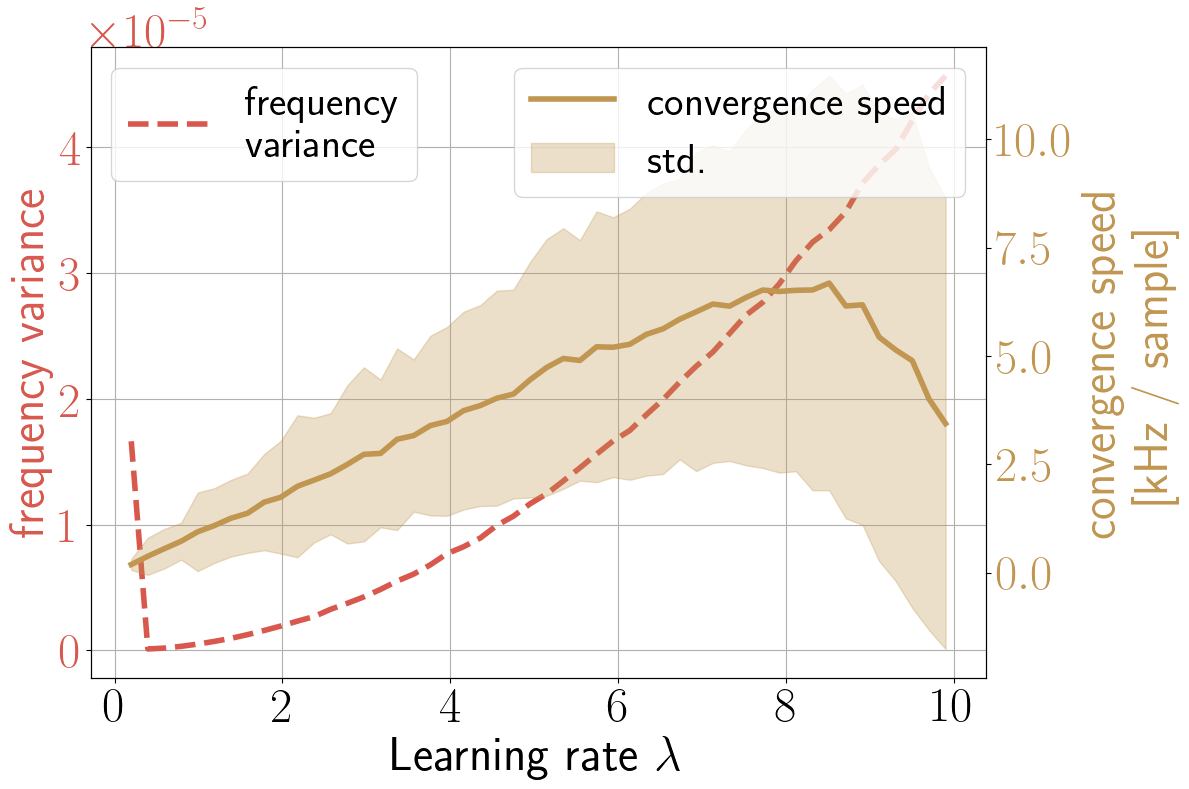

In [199]:
exp4_hann.group_by("lambda", n_bins=50)
lambda_bins = exp4_hann.group_data_bins
freq_scale = 1e-3 # Hz -> kHz
range_scale = 1e2
fmcw = FmcwRadar(exp4_hann.radar_parameters)

fig, ax = plt.subplots(1)

# ax.plot(lambda_bins[1:], exp4_hann.rmse_binned[1:] * freq_scale, label="oscillators error", c="C0")
# ax.set_xlabel("Learning rate $\lambda$")
# ax.set_ylabel("Error [kHz]", c="C0")
# # ax.set_xscale('log')
# ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
# # ax.ticklabel_format(scilimits=(0, 101))
# ax.tick_params(axis='y', labelcolor="C0")

# secay = ax.secondary_yaxis(
#     -0.15,
#     functions=(
#         lambda x: fmcw.get_range_from_freq(x * freq_scale**-1, negative=True) * range_scale,  # kHz → cm
#         lambda x: fmcw.get_freq_from_range(x * range_scale**-1) * freq_scale   # m → kHz (inverse)
#     )
# )
# secay.set_ylabel("Error [cm]", c="C0")
# secay.tick_params(axis='y', labelcolor="C0")

ax2 = ax#.twinx()
ax2.plot(lambda_bins, exp4_hann.frequency_variance_binned, 
         c="C1", 
         linestyle="--",
         label="frequency \nvariance")
# ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor="C1")
ax2.set_xlabel("Learning rate $\lambda$")
ax2.set_ylabel("frequency variance", c="C1")
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax3 = ax.twinx()
convergence_speed = exp4_hann.convergence_speed_binned * freq_scale
ax3.plot(lambda_bins, convergence_speed, c="C2", label='convergence speed')
speed_std = exp4_hann.convergence_speed_binned_std * freq_scale
min_speed = exp4_hann.convergence_speed_binned_min * freq_scale
max_speed = exp4_hann.convergence_speed_binned_max * freq_scale
ax3.fill_between(lambda_bins, 
                 convergence_speed - speed_std, 
                 convergence_speed + speed_std,
                 alpha=0.3, color="C2", label="std.")

ax3.set_ylabel("convergence speed \n[kHz / sample]", c="C2")
ax3.tick_params(axis='y', labelcolor="C2")

ax2.legend(loc=0)
ax3.legend(loc=1)
ax.grid()
plt.tight_layout()

plt.savefig("paper_figures/single_target_error_lambda.pdf", bbox_inches='tight')

In [200]:
exp4_hann = ExperimentAnalyser("../data/recorded_runs/single_target_amplitude_hann_test.npy")

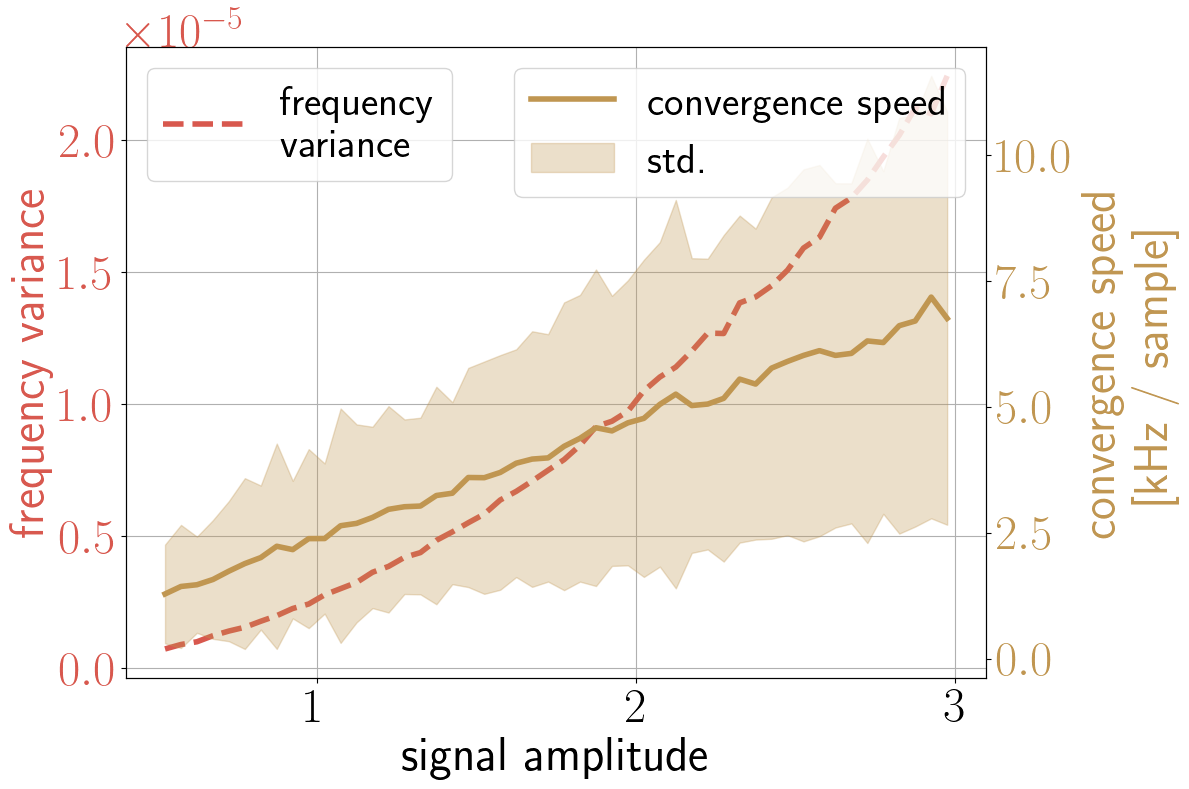

In [201]:
exp4_hann.group_by("signal_amplitude", n_bins=50)

amplitude_bins = exp4_hann.group_data_bins
freq_scale = 1e-3 # Hz -> kHz
range_scale = 1e2
fmcw = FmcwRadar(exp4_hann.radar_parameters)

fig, ax = plt.subplots(1)

# ax.plot(amplitude_bins, exp4_hann.rmse_binned * freq_scale, label="oscillators error", c="C0")

ax2 = ax#.twinx()
ax2.plot(amplitude_bins, exp4_hann.frequency_variance_binned, 
         c="C1", 
         linestyle="--",
         label="frequency \nvariance")
# ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor="C1")
ax.set_xlabel("signal amplitude")
ax2.set_ylabel("frequency variance", c="C1")
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax3 = ax.twinx()
convergence_speed = exp4_hann.convergence_speed_binned * freq_scale
ax3.plot(amplitude_bins, convergence_speed, c="C2", label="convergence speed")
speed_std = exp4_hann.convergence_speed_binned_std * freq_scale
min_speed = exp4_hann.convergence_speed_binned_min * freq_scale
max_speed = exp4_hann.convergence_speed_binned_max * freq_scale
ax3.fill_between(amplitude_bins, 
                 convergence_speed - speed_std, 
                 convergence_speed + speed_std,
                 alpha=0.3, color="C2", label="std.")

ax3.set_ylabel("convergence speed \n[kHz / sample]", c="C2")
ax3.tick_params(axis='y', labelcolor="C2")

ax2.legend(loc=0)
ax3.legend(loc=1)
ax.grid()
plt.tight_layout()

plt.savefig("paper_figures/single_target_error_amplitude.pdf", bbox_inches='tight')

# Two targets

In [66]:
exp_2targets_high_lambda_hann = ExperimentAnalyser("../data/recorded_runs/two_targets_hann_l05_image_no_hann.npy")

0.075


/tmp/ipykernel_300025/3583925025.py:43: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([0.0, 20000])


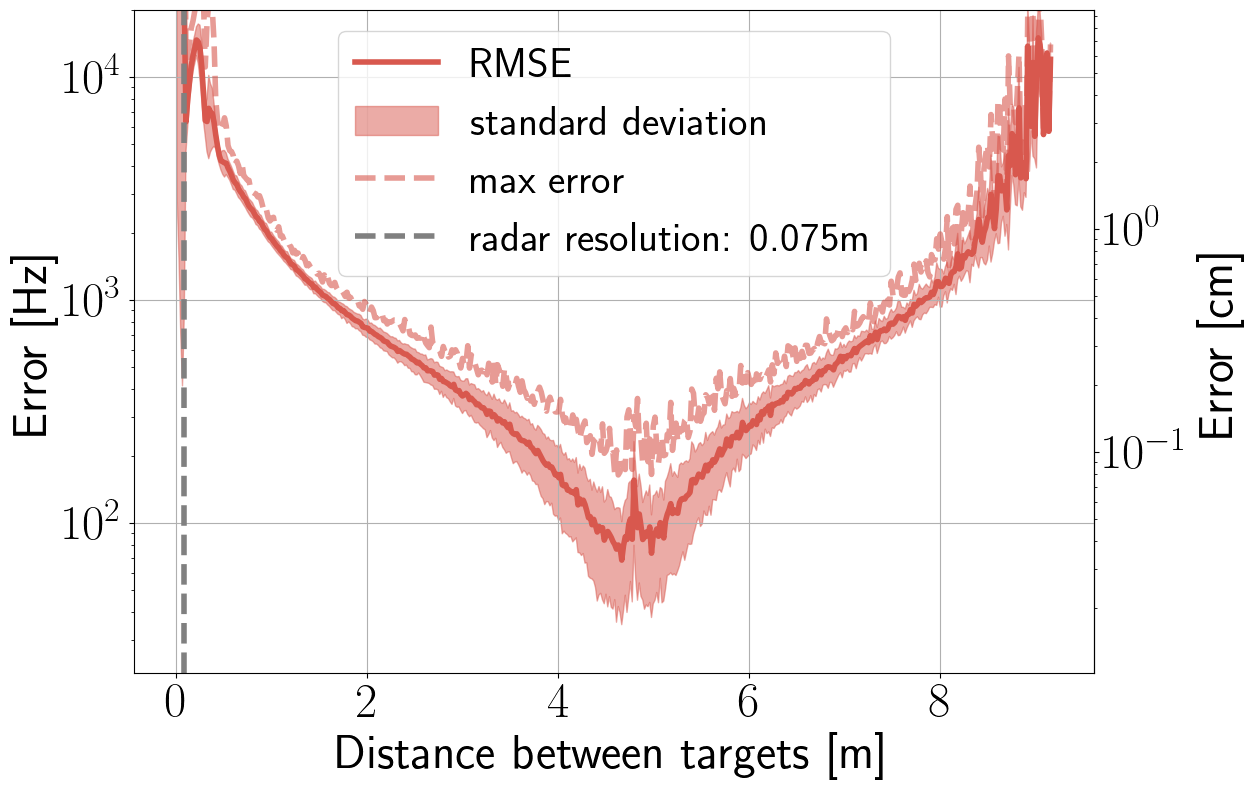

In [71]:

freq_scale = 1
fig, ax = plt.subplots(1)

fmcw = FmcwRadar(exp_2targets_high_lambda_hann.radar_parameters)

exp_2targets_high_lambda_hann.group_by("targets_distance", n_bins=500)

ax.plot(exp_2targets_high_lambda_hann.group_data_bins, 
         exp_2targets_high_lambda_hann.rmse_binned,
         label="RMSE", c="C1")

w_hann_std = exp_2targets_high_lambda_hann.std_binned
w_hann_max = exp_2targets_high_lambda_hann.max_errors_binned
ax.fill_between(exp_2targets_high_lambda_hann.group_data_bins, 
                 exp_2targets_high_lambda_hann.rmse_binned - w_hann_std, 
                 exp_2targets_high_lambda_hann.rmse_binned + w_hann_std,
                 alpha=0.5, color="C1", label="standard deviation")
ax.plot(exp_2targets_high_lambda_hann.group_data_bins, w_hann_max,
        c="C1", linestyle="--", label='max error', alpha=0.6)


radar_B = exp_2targets_high_lambda_hann.experiment_config["radar_config"]["B"]
radar_resolution = 3e8 / (2*radar_B)
print(radar_resolution)
ax.axvline(radar_resolution, label=f"radar resolution: {radar_resolution:.3f}m", c="grey", linestyle="--")

ax.legend()
ax.set_xlabel("Distance between targets [m]")
ax.set_ylabel("Error [Hz]")

secay = ax.secondary_yaxis(
    'right',
    functions=(
        lambda x: fmcw.get_range_from_freq(x * freq_scale**-1, negative=True) * 1e2,  # kHz → cm
        lambda x: fmcw.get_freq_from_range(x * 1e-2) * freq_scale   # m → kHz (inverse)
    )
)
secay.set_ylabel("Error [cm]")

ax.grid()
# ax.set_xlim([8.0, 10.0])
ax.set_yscale('log')
ax.set_ylim([0.0, 20000])

plt.tight_layout()
plt.savefig("paper_figures/two_targets_failed_convergence_vs_hann.png", bbox_inches="tight", dpi=300)

In [10]:
exp_2targets_l05 = ExperimentAnalyser("../data/recorded_runs/two_targets_hann_l05.npy")
exp_2targets_l2 = ExperimentAnalyser("../data/recorded_runs/two_targets_hann_l2.npy")
exp_2targets_l5 = ExperimentAnalyser("../data/recorded_runs/two_targets_hann_l05_B.npy")

In [11]:
exp_list = [exp_2targets_l05, exp_2targets_l2, exp_2targets_l5]
lambda_list = [0.5, 2.0, 5.0]

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1902422/674835619.py:13: SyntaxWarning: invalid escape sequence '\l'
  label=f"$\lambda: {lambda_list[i]}$", c=f"C{i}")


0.075


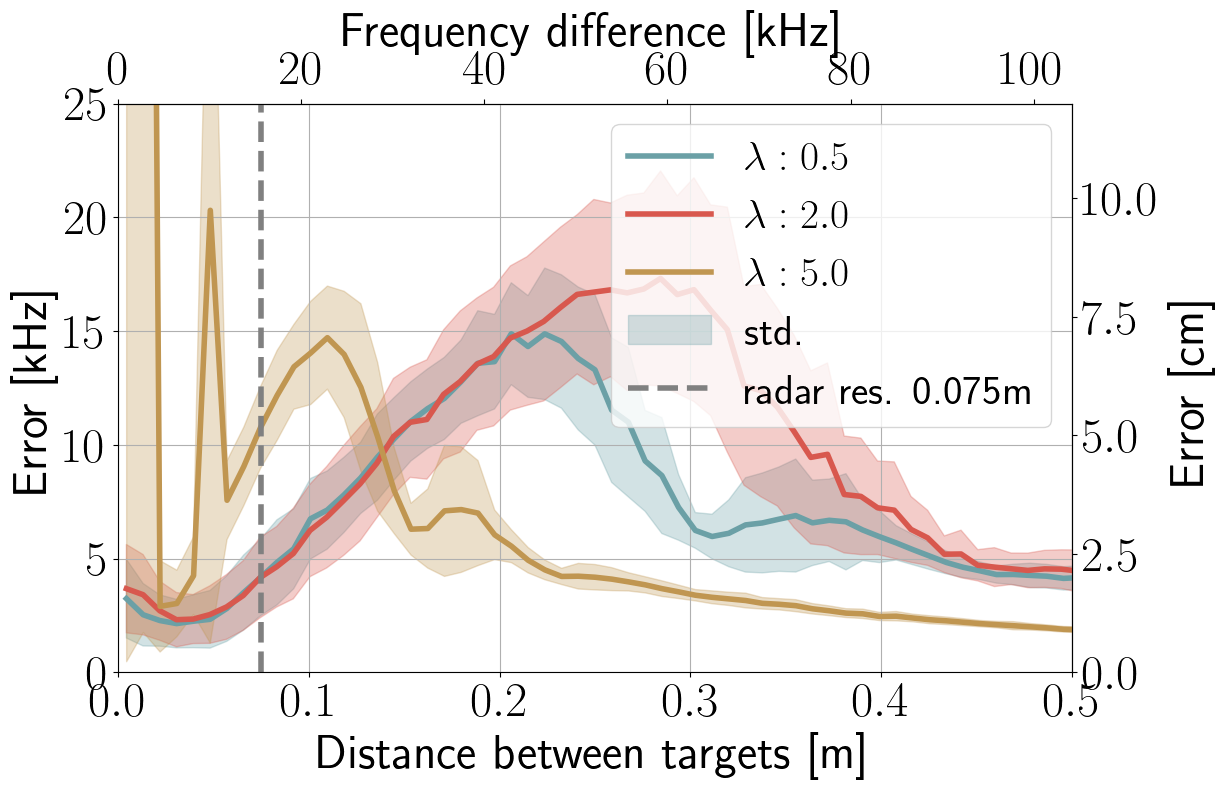

In [13]:

freq_scale = 1e-3
range_scale = 1e-2
fig, ax = plt.subplots(1)

fmcw = FmcwRadar(exp_2targets_l05.radar_parameters)


for i, exp in enumerate(exp_list):
    exp.group_by("targets_distance", n_bins=500)

    ax.plot(exp.group_data_bins, 
            exp.rmse_binned * freq_scale,
            label=f"$\lambda: {lambda_list[i]}$", c=f"C{i}")

for i, exp in enumerate(exp_list):
    w_hann_std = exp.std_binned * freq_scale
    w_hann_max = exp.max_errors_binned * freq_scale
    ax.fill_between(exp.group_data_bins, 
                    exp.rmse_binned * freq_scale - w_hann_std, 
                    exp.rmse_binned * freq_scale + w_hann_std,
                    alpha=0.3, color=f"C{i}", label="std." if i == 0 else None)
    # ax.plot(exp.group_data_bins, w_hann_max,
    #         c=f"C{i}", linestyle="--", label="max error" if i == 0 else None, alpha=0.3)

radar_B = exp_2targets_l05.experiment_config["radar_config"]["B"]
radar_resolution = 3e8 / (2*radar_B)
print(radar_resolution)
ax.axvline(radar_resolution, label=f"radar res. {radar_resolution:.3f}m", c="grey", linestyle="--")

ax.legend()
ax.set_xlabel("Distance between targets [m]")
ax.set_ylabel("Error [kHz]")

secay = ax.secondary_yaxis(
    'right',
    functions=(
        lambda x: fmcw.get_range_from_freq(x * freq_scale**-1, negative=True) * range_scale**-1,  # kHz → cm
        lambda x: fmcw.get_freq_from_range(x * range_scale) * freq_scale   # m → kHz (inverse)
    )
)
secay.set_ylabel("Error [cm]")

secax = ax.secondary_xaxis(
    'top',
    functions=(
        lambda x: fmcw.get_freq_from_range(x)  * 1e-3,  # m -> kHz
        lambda x: fmcw.get_range_from_freq(x * 1e3)   # kHz -> m (inverse)
    )
)
secax.set_xlabel("Frequency difference [kHz]")

ax.grid()
ax.set_xlim([0.0, 0.5])
ax.set_ylim([0.0, 25])

plt.tight_layout()
plt.savefig("paper_figures/two_targets_error_hann.pdf", bbox_inches="tight", dpi=300)

In [5]:
exp_2targets_l05_20db = ExperimentAnalyser("../data/recorded_runs/two_targets_hann_l05.npy")
exp_2targets_l05_10db = ExperimentAnalyser("../data/recorded_runs/two_targets_hann_l05_10db.npy")
exp_2targets_l05_00db = ExperimentAnalyser("../data/recorded_runs/two_targets_hann_l05_00db.npy")

In [6]:
exp_list = [exp_2targets_l05_20db, exp_2targets_l05_10db, exp_2targets_l05_00db]
db_list = [20, 10, 0]

0.075


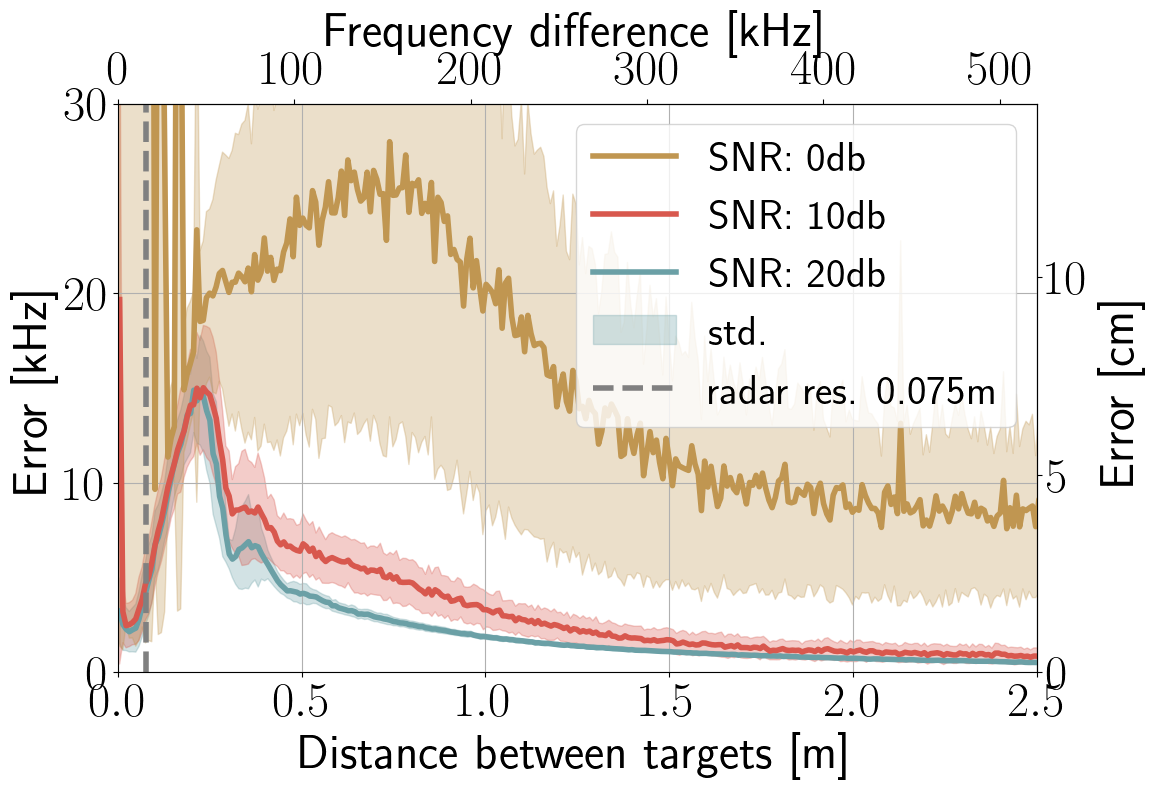

In [8]:

freq_scale = 1e-3
range_scale = 1e-2
fig, ax = plt.subplots(1)

fmcw = FmcwRadar(exp_2targets_l05_20db.radar_parameters)


for i, exp in enumerate(exp_list):
    exp.group_by("targets_distance", n_bins=500)

    ax.plot(exp.group_data_bins, 
            exp.rmse_binned * freq_scale,
            label=f"SNR: {db_list[i]}db", c=f"C{i}")

for i, exp in enumerate(exp_list):
    w_hann_std = exp.std_binned * freq_scale
    w_hann_max = exp.max_errors_binned * freq_scale
    ax.fill_between(exp.group_data_bins, 
                    exp.rmse_binned * freq_scale - w_hann_std, 
                    exp.rmse_binned * freq_scale + w_hann_std,
                    alpha=0.3, color=f"C{i}", label="std." if i == 0 else None)
    # ax.plot(exp.group_data_bins, w_hann_max,
    #         c=f"C{i}", linestyle="--", label="max error" if i == 0 else None, alpha=0.3)

radar_B = exp_2targets_l05_20db.experiment_config["radar_config"]["B"]
radar_resolution = 3e8 / (2*radar_B)
print(radar_resolution)
ax.axvline(radar_resolution, label=f"radar res. {radar_resolution:.3f}m", c="grey", linestyle="--")

ax.legend()
handles, labels = plt.gca().get_legend_handles_labels()
order = [2,1,0,3,4]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
ax.set_xlabel("Distance between targets [m]")
ax.set_ylabel("Error [kHz]")

secay = ax.secondary_yaxis(
    'right',
    functions=(
        lambda x: fmcw.get_range_from_freq(x * freq_scale**-1, negative=True) * range_scale**-1,  # kHz → cm
        lambda x: fmcw.get_freq_from_range(x * range_scale) * freq_scale   # m → kHz (inverse)
    )
)
secay.set_ylabel("Error [cm]")

secax = ax.secondary_xaxis(
    'top',
    functions=(
        lambda x: fmcw.get_freq_from_range(x)  * 1e-3,  # m -> kHz
        lambda x: fmcw.get_range_from_freq(x * 1e3)   # kHz -> m (inverse)
    )
)
secax.set_xlabel("Frequency difference [kHz]")

ax.grid()
ax.set_xlim([0.0, 2.5])
ax.set_ylim([0.0, 30])

plt.tight_layout()
plt.savefig("paper_figures/two_targets_error_hann_noise.pdf", bbox_inches="tight", dpi=300)

In [18]:
exp_2targets_l05 = ExperimentAnalyser("../data/recorded_runs/two_targets_hann_l05_image_full.npy")
exp_2targets_l05_detail = ExperimentAnalyser("../data/recorded_runs/two_targets_hann_l05_image.npy")

In [19]:
from scipy import stats

In [20]:
ws_targ = exp_2targets_l05.extracted_data['target_frequencies']
error = exp_2targets_l05.extracted_data['avg_error']

ws_targ_detail = exp_2targets_l05_detail.extracted_data['target_frequencies']
error_detail = exp_2targets_l05_detail.extracted_data['avg_error']

In [21]:
# ws_start = exp_2targets_l05.extracted_data['starting_frequencies']
# ws_start_detail = exp_2targets_l05_detail.extracted_data['starting_frequencies']

In [25]:
ret = stats.binned_statistic_2d(ws_targ[:, 0], ws_targ[:, 1], np.square(error), 'mean', expand_binnumbers=True, bins=35)
ret_detail = stats.binned_statistic_2d(ws_targ_detail[:, 0], ws_targ_detail[:, 1], np.square(error_detail), 'mean', expand_binnumbers=True, bins=200)

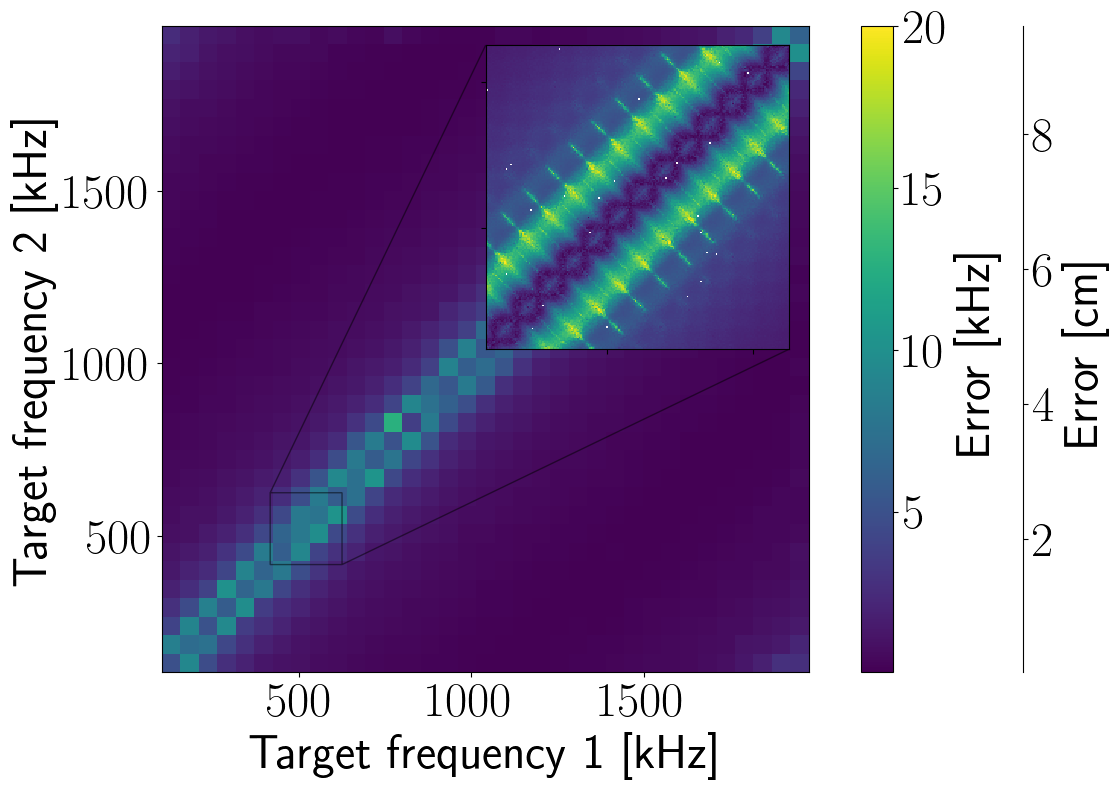

In [ ]:
fig, ax = plt.subplots(1)

fmcw = FmcwRadar(exp_2targets_l05.radar_parameters)

freq_scale = 1e-3 #Hz -> kHz
img_extent = np.array([ret.y_edge[0],
                  ret.y_edge[-1],
                  ret.x_edge[0],
                  ret.x_edge[-1]])
img_extent *= freq_scale

c = ax.imshow(np.sqrt(ret.statistic)*freq_scale, interpolation='none', 
          extent=img_extent, origin='lower', vmax=20000*freq_scale);
cbar = plt.colorbar(c, ax=ax);

# inset Axes....
img_extent_detail = np.array([ret_detail.y_edge[0],
                  ret_detail.y_edge[-1],
                  ret_detail.x_edge[0],
                  ret_detail.x_edge[-1]])
img_extent_detail *= freq_scale

f1 = fmcw.get_freq_from_range(2.0) * freq_scale
f2 = fmcw.get_freq_from_range(3.0) * freq_scale
x1, x2, y1, y2 = f1, f2, f1, f2  # subregion of the original image
axins = ax.inset_axes(
    [0.5, 0.5, 0.47, 0.47],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
axins.imshow(np.sqrt(ret_detail.statistic)*freq_scale, interpolation='none', 
          extent=img_extent_detail, origin='lower', vmax=20000*freq_scale);

ax.indicate_inset_zoom(axins, edgecolor="black")

secay = cbar.ax.secondary_yaxis(
    5,
    functions=(
        lambda x: fmcw.get_range_from_freq(x*freq_scale**-1, negative=True) * 1e2,  # kHz → cm
        lambda x: fmcw.get_freq_from_range(x * 1e-2) * freq_scale   # m → kHz (inverse)
    )
)
secay.set_ylabel("Error [cm]")

ax.set_xlabel("Target frequency 1 [kHz]");
ax.set_ylabel("Target frequency 2 [kHz]");
cbar.ax.set_ylabel("Error [kHz]")

plt.tight_layout()
# plt.savefig("paper_figures/two_targets_error_image.pdf", bbox_inches="tight", dpi=100)
